# Reclustering Airway Epithelium Cells (res=0.4)

Load data

In [5]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

NEW_OBJ = "airway-epithelium"
NEW_OBJ_V = 'reclustered'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / NEW_OBJ / 'h5ad' / f'{NEW_OBJ}-{NEW_OBJ_V}.h5ad'

In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
print(comb.obs['ann_lvl_3'].unique().tolist())

['PC_IgA', 'Fib', 'Neut', 'T', 'SMC', 'Endo', 'Amb', 'Mac', 'PC_IgG', 'PC_IgA_IgG', 'B', 'Mast', 'actFib', 'AT2', 'AlvMac', 'basal', 'AT1', 'ciliated', 'PC_IgM', 'secretory', 'goblet']


## Subset Airway Epithelium Types

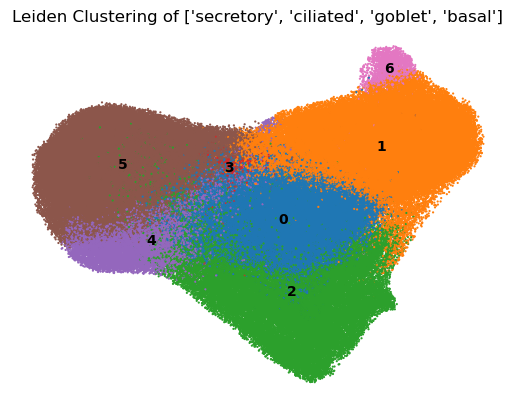

In [78]:
cts = ['secretory','ciliated','goblet','basal']

sub = comb[comb.obs["ann_lvl_3"].isin(cts)].copy()

rsc.pp.neighbors(
    sub,
    use_rep="X_resolvi",
    n_neighbors= 10,
    random_state=SEED_VALUE
)

rsc.tl.umap(
    sub,
    random_state=SEED_VALUE,
)

rsc.tl.leiden(sub, resolution=0.4, random_state=SEED_VALUE)

sc.pl.umap(sub, color=["leiden"],size=10, legend_loc="on data", frameon=False, title=f"Leiden Clustering of {cts}")

Get cluster markers

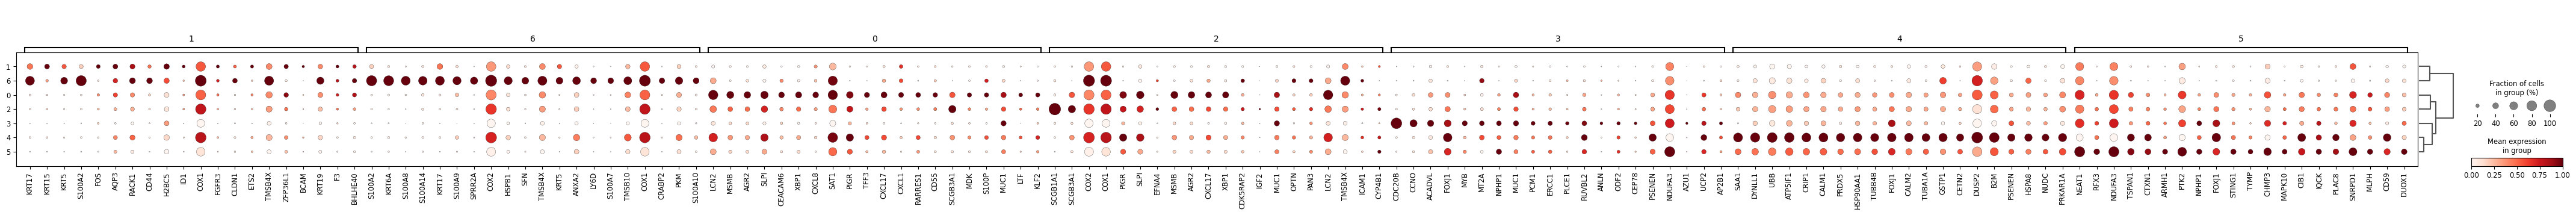

In [85]:
# get marker genes and dotplot

res_name = 'leiden'

rsc.tl.rank_genes_groups(
    sub, 
    groupby=res_name,
    method="wilcoxon",
)

sc.tl.dendrogram(sub, groupby=res_name)

# dotplot
dp = sc.pl.rank_genes_groups_dotplot(
    sub,
    groupby=res_name,
    standard_scale="var",
    n_genes=20, # noramlly 5 
    show=False,
    return_fig=True,   # returns a DotPlot object
)

dp.show()


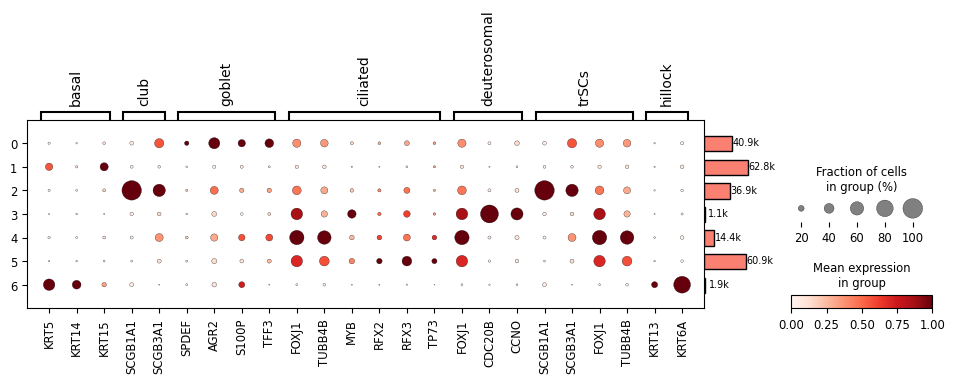

In [82]:
import json
# load canonical markers
all_markers_path = 'code/canonical_markers/all_markers.json'
with open(all_markers_path, 'r') as f:
    all_markers = json.load(f)
# NOTE: check python file, some genes are suposed to be low/not expressed in some cell types

res_name = "leiden"

all_markers = {
    'basal': ['KRT5', 'KRT14', 'KRT15'],
    'club': ['SCGB1A1', 'SCGB3A1'],
    'goblet': ['SPDEF','AGR2','S100P','TFF3'],
    'ciliated': ['FOXJ1', 'TUBB4B', 'MYB', 'RFX2', 'RFX3', 'TP73'],
    'deuterosomal': ['FOXJ1','CDC20B', 'CCNO'],
    'trSCs' : ['SCGB1A1', 'SCGB3A1', 'FOXJ1', 'TUBB4B'],
    'hillock': ["KRT13","KRT6A"]
}

dp = sc.pl.dotplot(
        sub, 
        all_markers, 
        groupby=res_name, 
        standard_scale='var', 
        #layer="resolvi_normalized",
        return_fig=True
    )
# adding cell counts to the dotplot
dp.add_totals().show()


In [84]:
cluster_condition_counts = pd.crosstab(
    sub.obs["leiden"],
    comb.obs["condition"]
)

cluster_condition_counts

condition,CF,CF_ETI,CTRL
leiden,,,
0,34572,5305,979
1,53895,3949,4996
2,20175,2682,14034
3,945,43,138
4,12147,1409,809
5,51496,4431,4963
6,1777,64,22


Name clusters

In [6]:
sub = sc.read_h5ad(NEW_OBJ_PATH)

In [7]:
clusters_map = {
    # airway sub1thelium
    "1": "BC",
    "2": "Club",
    "0": "Gob",
    "3": "Deu",
    "6": "Hillock",
    "4": "MCC", # mature 
    "5": "MCC" # stressed/differentitating
}


CT_KEY = 'reclustered_ct'
CLUSTERS_KEY = 'leiden'
sub.obs[CT_KEY] = sub.obs[CLUSTERS_KEY].map(clusters_map).astype('category')

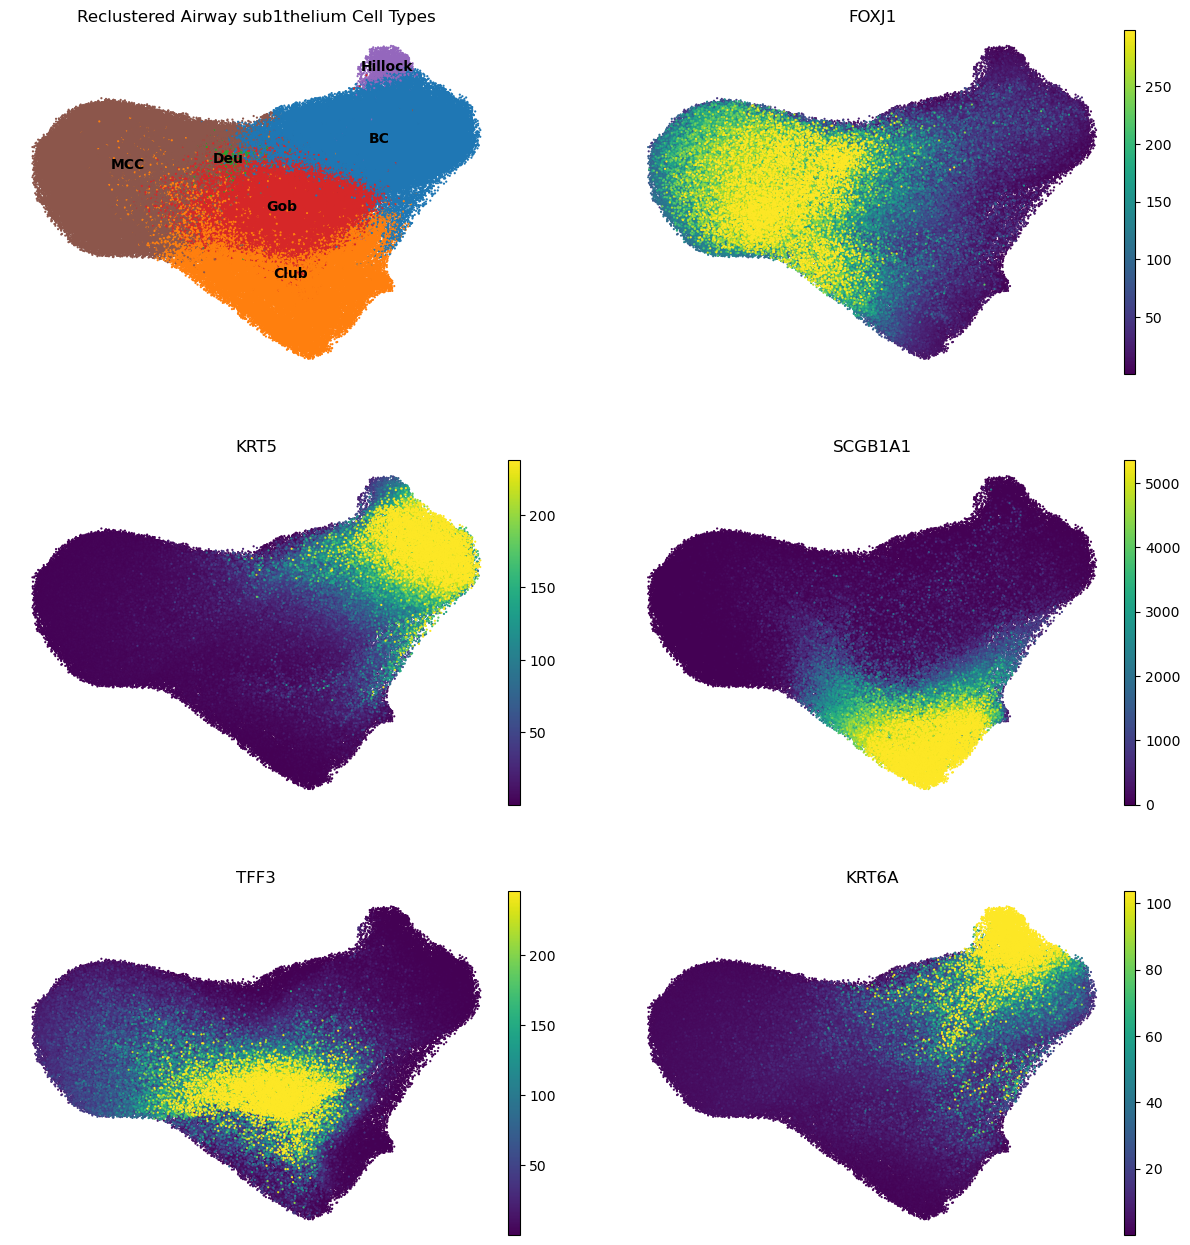

In [8]:
sc.pl.umap(
    sub, 
    color=[CT_KEY,"FOXJ1","KRT5","SCGB1A1","TFF3","KRT6A"], 
    size=10, 
    legend_loc="on data", 
    frameon=False, 
    title="Reclustered Airway sub1thelium Cell Types",
    layer='resolvi_normalized',
    vmax='p98',
    ncols=2
)

See how the annotations changed

In [9]:
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

OLD_ANN_KEY = 'ann_lvl_3'
NEW_ANN_KEY = 'reclustered_ct'


# Keep only cells with both values
comparison = sub.obs[[OLD_ANN_KEY, NEW_ANN_KEY]].dropna().copy()

comparison[OLD_ANN_KEY] = comparison[OLD_ANN_KEY].astype(str)
comparison[NEW_ANN_KEY] = comparison[NEW_ANN_KEY].astype(str)

# -------------------------------------------------
# 1. Composition of every Leiden cluster
# -------------------------------------------------
counts = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
)

display(counts)

# Percentage composition within each Leiden cluster
percent_within_ann = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
    normalize="index",
) * 100

display(percent_within_ann.round(1))

reclustered_ct,BC,Club,Deu,Gob,Hillock,MCC
ann_lvl_3,,,,,,
basal,61194,1575,3,5722,1859,1272
ciliated,1467,2229,1115,13615,0,73895
goblet,35,53,2,19962,4,16
secretory,144,33034,6,1557,0,72


reclustered_ct,BC,Club,Deu,Gob,Hillock,MCC
ann_lvl_3,,,,,,
basal,85.4,2.2,0.0,8.0,2.6,1.8
ciliated,1.6,2.4,1.2,14.7,0.0,80.0
goblet,0.2,0.3,0.0,99.5,0.0,0.1
secretory,0.4,94.9,0.0,4.5,0.0,0.2


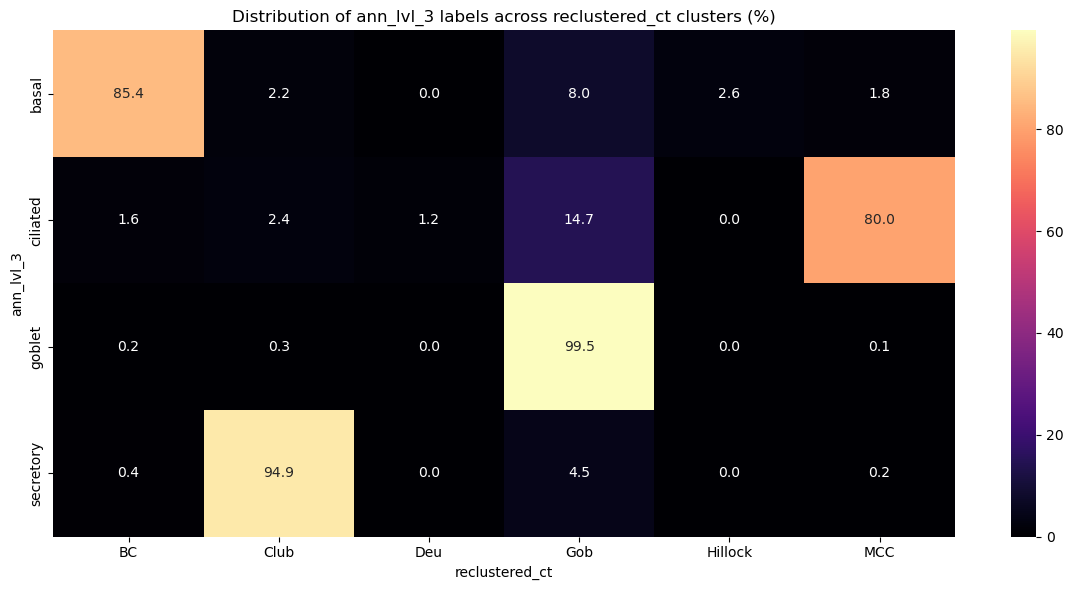

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(percent_within_ann, cmap="magma", annot=True, fmt=".1f")
plt.xlabel(NEW_ANN_KEY)
plt.ylabel(OLD_ANN_KEY)
plt.title(f"Distribution of {OLD_ANN_KEY} labels across {NEW_ANN_KEY} clusters (%)")
plt.tight_layout()
plt.show()

save object with annotations

In [11]:
NEW_OBJ_PATH.parent.mkdir(parents=True, exist_ok=True)
sub.write_h5ad(NEW_OBJ_PATH)